# Business Questions


**Q1:** Provide the work out exactly how we differentiate between Reclaims and Renewals.

**Q2:** What was the paid net growth on the 20th of September.

**Q3:** How many people were on a trial on the 1st of October? Include both people who started a trial and ended a trial on that day.

**Q4:** Plot a graph that shows the paid net growth each month between June and December.

**Q5:** Plot a graph that shows the size of the paid base each day between June 1st and December 31st, split by 1, 3 and 12 month subscribers and Acquisitions/Reclaims/Renewals.

**Q6:** Using knowledge of the gaming industry, explain the findings.

### STEP 1:  Importing libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### STEP 2:  Load the Dataset

In [ ]:
df = pd.read_csv('/content/playstation.csv')

#checking the data, if it is loaded
df.head()

,ACCT_ID,SUBSCRIPTION_BILLABLE_TYPE,SUBSCRIPTION_TYPE,SKU_LENGTH,SUB_STATE,SUB_START_DATE,SUB_END_DATE
0,1.883680e+14,Paid,Wallet,1 month,Reclaim,2020-03-15,2020-04-15
1,1.883680e+14,Paid,Wallet,1 month,Renewal,2020-04-15,2020-05-15
2,1.883680e+14,Paid,Wallet,1 month,Renewal,2020-05-16,2020-06-16
3,1.883680e+14,Paid,Wallet,1 month,Renewal,2020-06-16,2020-07-16
4,1.883680e+14,Paid,Wallet,1 month,Renewal,2020-07-16,2020-08-16


### STEP 3: Data Preprocessing

In [ ]:
# Ensuring that we have the correct Data-types
df.dtypes

#here we notice that the columns ('SUB_START_DATE' & 'SUB_END_DATE') needs to be converted into "datetime"


,0
ACCT_ID,float64
SUBSCRIPTION_BILLABLE_TYPE,object
SUBSCRIPTION_TYPE,object
SKU_LENGTH,object
SUB_STATE,object
SUB_START_DATE,object
SUB_END_DATE,object


In [ ]:
# Converting dates to datetime
df['SUB_START_DATE'] = pd.to_datetime(df['SUB_START_DATE'])
df['SUB_END_DATE'] = pd.to_datetime(df['SUB_END_DATE'])

df.dtypes

,0
ACCT_ID,float64
SUBSCRIPTION_BILLABLE_TYPE,object
SUBSCRIPTION_TYPE,object
SKU_LENGTH,object
SUB_STATE,object
SUB_START_DATE,datetime64[ns]
SUB_END_DATE,datetime64[ns]


In [ ]:
# check for null values
df.isnull().sum()

,0
ACCT_ID,0
SUBSCRIPTION_BILLABLE_TYPE,0
SUBSCRIPTION_TYPE,0
SKU_LENGTH,0
SUB_STATE,0
SUB_START_DATE,0
SUB_END_DATE,0


In [ ]:
# now we create additional columns(e.g., 'Reclaims' & 'Renewals') to later answer our questions.
# This differentiation is crucial for further analysis, especially when we want to understand customer behavior and subscription patterns.

# Identifying the type of subscription for differentiation
df['Is_Reclaim'] = df['SUB_STATE'].apply(lambda x: 1 if x == 'Reclaim' else 0)
df['Is_Renewal'] = df['SUB_STATE'].apply(lambda x: 1 if x == 'Renewal' else 0)

df

,ACCT_ID,SUBSCRIPTION_BILLABLE_TYPE,SUBSCRIPTION_TYPE,SKU_LENGTH,SUB_STATE,SUB_START_DATE,SUB_END_DATE,Is_Reclaim,Is_Renewal
0,1.883680e+14,Paid,Wallet,1 month,Reclaim,2020-03-15,2020-04-15,1,0
1,1.883680e+14,Paid,Wallet,1 month,Renewal,2020-04-15,2020-05-15,0,1
2,1.883680e+14,Paid,Wallet,1 month,Renewal,2020-05-16,2020-06-16,0,1
3,1.883680e+14,Paid,Wallet,1 month,Renewal,2020-06-16,2020-07-16,0,1
4,1.883680e+14,Paid,Wallet,1 month,Renewal,2020-07-16,2020-08-16,0,1
...,...,...,...,...,...,...,...,...,...
28256,6.755420e+14,Paid,Wallet,1 month,Renewal,2020-12-14,2021-01-14,0,1
28257,3.016940e+14,Paid,Retail,3 months,Acquisition,2019-09-27,2019-12-27,0,0
28258,3.016940e+14,Paid,Retail,3 months,Reclaim,2020-04-16,2020-07-16,1,0
28259,3.016940e+14,Paid,Retail,3 months,Renewal,2020-07-25,2020-10-25,0,1


### STEP 4: Answering Business Questions

Q1: Differentiate Between Reclaims and Renewals

In [ ]:

reclaims = df[df['Is_Reclaim'] == 1]
renewals = df[df['Is_Renewal'] == 1]


# Concatenating reclaims & renewals into a df
reclaims_renewals_df = pd.concat([reclaims, renewals])


# Chekcing the new dataframe
reclaims_renewals_df.head()


,ACCT_ID,SUBSCRIPTION_BILLABLE_TYPE,SUBSCRIPTION_TYPE,SKU_LENGTH,SUB_STATE,SUB_START_DATE,SUB_END_DATE,Is_Reclaim,Is_Renewal
0,1.883680e+14,Paid,Wallet,1 month,Reclaim,2020-03-15,2020-04-15,1,0
6,1.883680e+14,Paid,Wallet,1 month,Reclaim,2020-10-19,2020-11-19,1,0
8,3.323170e+14,Paid,Wallet,1 month,Reclaim,2019-07-16,2019-08-16,1,0
41,5.483780e+14,Paid,Wallet,1 month,Reclaim,2019-07-27,2019-08-27,1,0
42,5.483780e+14,Paid,Wallet,1 month,Reclaim,2019-10-05,2019-11-05,1,0


In [ ]:
# Count the reclaims
reclaim_count = df['Is_Reclaim'].sum()

# Count the renewals
renewal_count = df['Is_Renewal'].sum()

# Total number the counts
print(f"Number of reclaims: {reclaim_count}")
print(f"Number of renewals: {renewal_count}")

Number of reclaims: 4369
Number of renewals: 18352


In [ ]:
# Created 2 additional columns ("SUB_DURATION_DAYS" &	"SUB_DURATION")

# Calculate subscription duration in days
df['SUB_DURATION_DAYS'] = (df['SUB_END_DATE'] - df['SUB_START_DATE']).dt.days

# Create a new column 'SUB_DURATION' based on the duration in days
df['SUB_DURATION'] = pd.cut(df['SUB_DURATION_DAYS'],
                               bins=[0, 30, 90, 365, float('inf')],
                               labels=['1 Month', '3 Months', '12 Months', 'Other'],
                               include_lowest=True,
                               right=False)

df


,ACCT_ID,SUBSCRIPTION_BILLABLE_TYPE,SUBSCRIPTION_TYPE,SKU_LENGTH,SUB_STATE,SUB_START_DATE,SUB_END_DATE,Is_Reclaim,Is_Renewal,SUB_DURATION_DAYS,SUB_DURATION
0,1.883680e+14,Paid,Wallet,1 month,Reclaim,2020-03-15,2020-04-15,1,0,31,3 Months
1,1.883680e+14,Paid,Wallet,1 month,Renewal,2020-04-15,2020-05-15,0,1,30,3 Months
2,1.883680e+14,Paid,Wallet,1 month,Renewal,2020-05-16,2020-06-16,0,1,31,3 Months
3,1.883680e+14,Paid,Wallet,1 month,Renewal,2020-06-16,2020-07-16,0,1,30,3 Months
4,1.883680e+14,Paid,Wallet,1 month,Renewal,2020-07-16,2020-08-16,0,1,31,3 Months
...,...,...,...,...,...,...,...,...,...,...,...
28256,6.755420e+14,Paid,Wallet,1 month,Renewal,2020-12-14,2021-01-14,0,1,31,3 Months
28257,3.016940e+14,Paid,Retail,3 months,Acquisition,2019-09-27,2019-12-27,0,0,91,12 Months
28258,3.016940e+14,Paid,Retail,3 months,Reclaim,2020-04-16,2020-07-16,1,0,91,12 Months
28259,3.016940e+14,Paid,Retail,3 months,Renewal,2020-07-25,2020-10-25,0,1,92,12 Months


Q2: Paid Net Growth on September 20

**Paid Net Growth = New Paid Subscribers - Churned Paid Subscribers**

In [ ]:
# This involves "counting new paid subscribers" and "subtracting churned paid subscribers" for "September 20".


# Filter for September 20th
sept_20_data = df[(df['SUB_START_DATE'] == '2020-09-20') | (df['SUB_END_DATE'] == '2020-09-20')]

# Calculate new paid subscribers
new_paid_subs = sept_20_data[(sept_20_data['SUB_START_DATE'] == '2020-09-20') & (sept_20_data['SUBSCRIPTION_BILLABLE_TYPE'] == 'Paid')].shape[0]


# Calculate churned paid subscribers
churned_paid_subs = sept_20_data[(sept_20_data['SUB_END_DATE'] == '2020-09-20') & (sept_20_data['SUBSCRIPTION_BILLABLE_TYPE'] == 'Paid')].shape[0]

# Calculate paid net growth
paid_net_growth = new_paid_subs - churned_paid_subs

print(f"Paid Net Growth on September 20th, 2020: {paid_net_growth}")



Paid Net Growth on September 20th, 2020: 6


Q3: Trial Subscribers on October 1

Now we "count the number of users on a trial on October 1st".                                                                                                                  
This includes users who started and ended their trials on 1 October.

In [ ]:

oct_1_trials = df[(df['SUB_START_DATE'] == '2020-10-01') | (df['SUB_END_DATE'] == '2020-10-01')]

# Filter for trials and store in a dataframe
trial_subscribers_df = oct_1_trials[oct_1_trials['SUBSCRIPTION_TYPE'] == 'Trial']

# Check the dataframe
trial_subscribers_df


,ACCT_ID,SUBSCRIPTION_BILLABLE_TYPE,SUBSCRIPTION_TYPE,SKU_LENGTH,SUB_STATE,SUB_START_DATE,SUB_END_DATE,Is_Reclaim,Is_Renewal,SUB_DURATION_DAYS,SUB_DURATION,Month
4615,5.888360e+14,Free,Trial,14 days,Trial,2020-09-17,2020-10-01,0,0,14,1 Month,2020-09
23331,6.965070e+14,Free,Trial,14 days,Trial,2020-10-01,2020-10-15,0,0,14,1 Month,2020-10


In [ ]:
# here we have trials for October

trial_count_df = oct_1_trials[oct_1_trials['SUBSCRIPTION_TYPE'] == 'Trial'].count()
trial_count_df

,0
ACCT_ID,2
SUBSCRIPTION_BILLABLE_TYPE,2
SUBSCRIPTION_TYPE,2
SKU_LENGTH,2
SUB_STATE,2
SUB_START_DATE,2
SUB_END_DATE,2
Is_Reclaim,2
Is_Renewal,2
SUB_DURATION_DAYS,2


Q4: Paid Net Growth Each Month (June to December)

In [ ]:
# Extract the Month
df['Month'] = df['SUB_START_DATE'].dt.to_period("M")


#Calculating Monthly Paid Net Growth

# Filtered for Paid subscriptions and group by month
monthly_growth = df[df['SUBSCRIPTION_BILLABLE_TYPE'] == 'Paid'].groupby('Month').size()

monthly_growth



,0
Month,
2019-06,1048
2019-07,957
2019-08,966
2019-09,1074
2019-10,1072
2019-11,1136
2019-12,1390
2020-01,1320
2020-02,1131


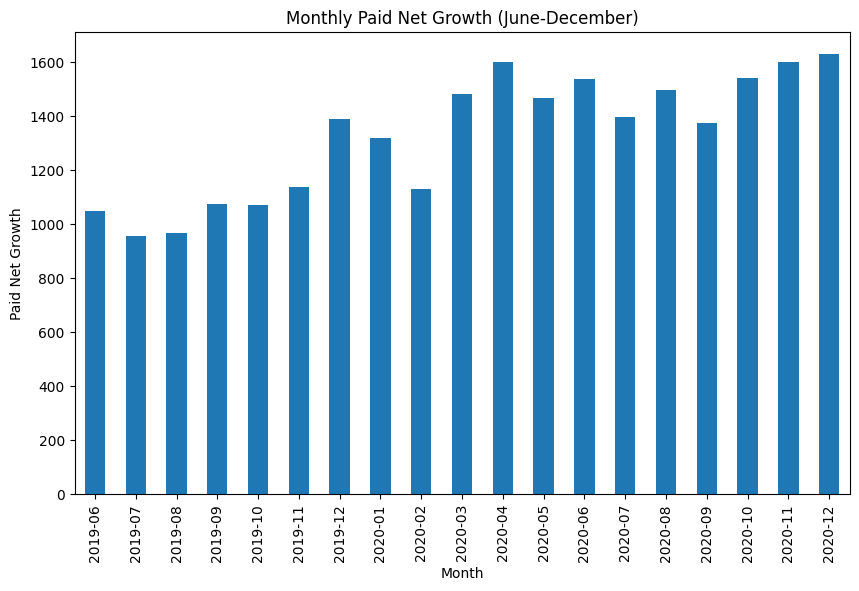

In [ ]:
# Plotting the data
monthly_growth.plot(kind='bar', figsize=(10, 6))
plt.title('Monthly Paid Net Growth (June-December)')
plt.xlabel('Month')
plt.ylabel('Paid Net Growth')
plt.show()

Q5: Daily Size of Paid Base (June to December) broken down by subscription duration (1, 3, and 12 months) and by acquisition type (Acquisitions/Reclaims/Renewals).

### **Data Filtering**

In [ ]:
# Filter data for date range (June 1st to December 31st) and paid subscriptions
filtered_df = df[(df['SUB_START_DATE'] >= '2020-06-01') & (df['SUB_END_DATE'] <= '2020-12-31') & (df['SUBSCRIPTION_TYPE'] == 'Wallet')]

# Created a new column to categorize Acquisitions/Reclaims/Renewals
filtered_df['AcquisitionType'] = 'Acquisition'
filtered_df.loc[filtered_df['Is_Reclaim'] == 1, 'AcquisitionType'] = 'Reclaim'
filtered_df.loc[filtered_df['Is_Renewal'] == 1, 'AcquisitionType'] = 'Renewal'

# Grouped data by date, subscription duration, and acquisition type, then count unique accounts
daily_data = filtered_df.groupby(['SUB_START_DATE', 'SUB_DURATION', 'AcquisitionType'])['ACCT_ID'].nunique().reset_index()

# Pivot the data for plotting
daily_data_pivot = daily_data.pivot_table(index='SUB_START_DATE', columns=['SUB_DURATION', 'AcquisitionType'], values='ACCT_ID', fill_value=0)


<ipython-input-184-6d7f83821ea4>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['AcquisitionType'] = 'Acquisition'
<ipython-input-184-6d7f83821ea4>:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily_data = filtered_df.groupby(['SUB_START_DATE', 'SUB_DURATION', 'AcquisitionType'])['ACCT_ID'].nunique().reset_index()
<ipython-input-184-6d7f83821ea4>:13: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the c

### **Now visualizing**

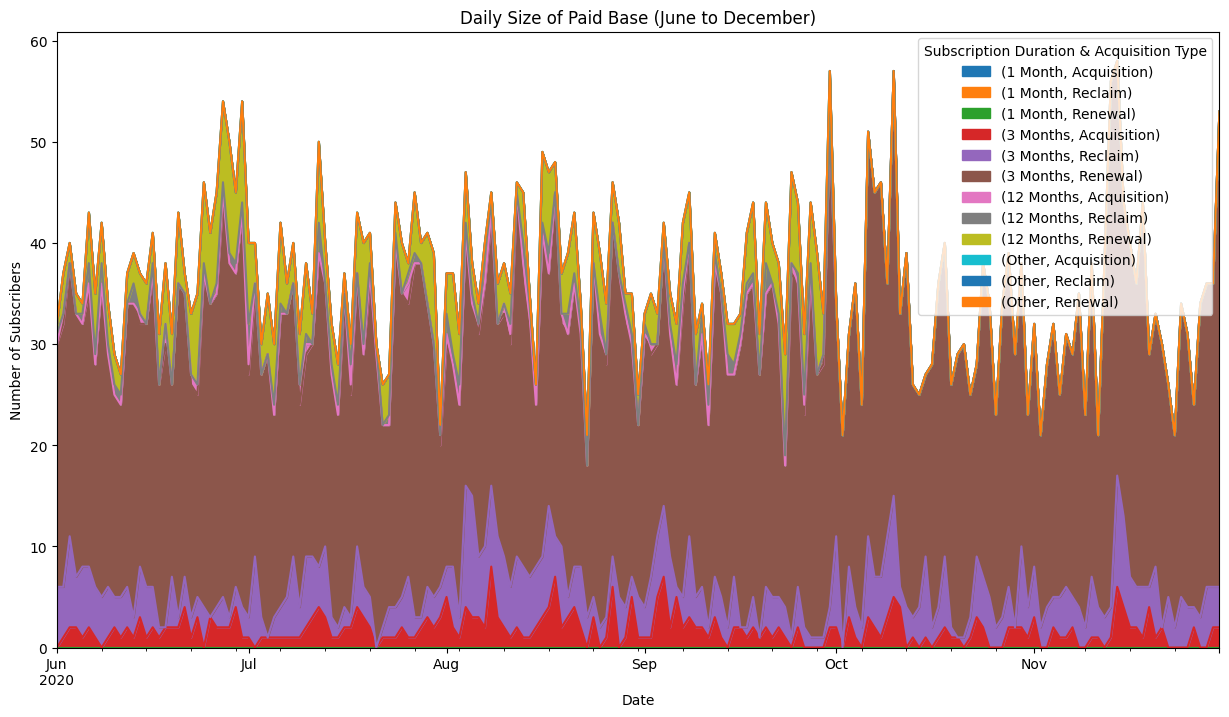

In [ ]:
# Plot the data
daily_data_pivot.plot(kind='area', stacked=True, figsize=(15, 8))
plt.title('Daily Size of Paid Base (June to December)')
plt.xlabel('Date')
plt.ylabel('Number of Subscribers')
plt.legend(title='Subscription Duration & Acquisition Type')
plt.show()




### STEP 5: Data Visualization

**Q4 Visualization: Line plot showing  monthly paid net growth**.

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

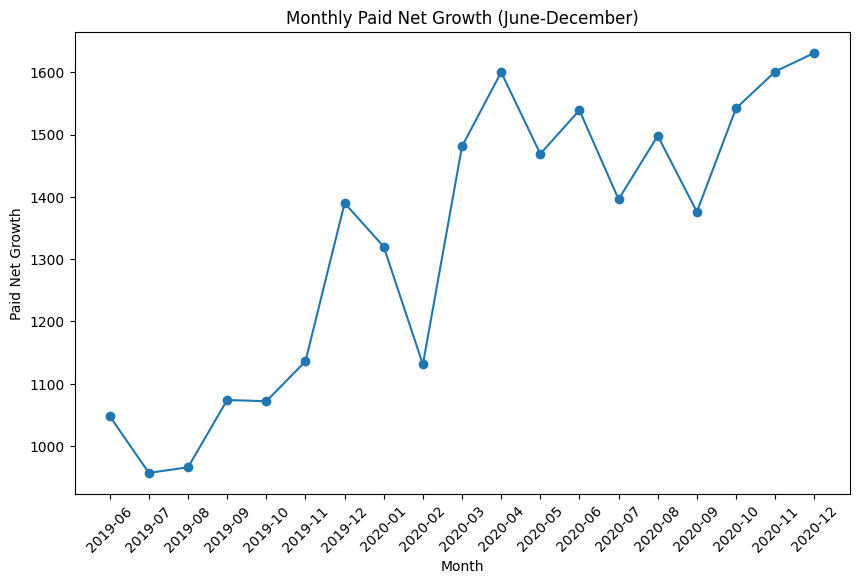

In [ ]:
# Plotting the data
plt.figure(figsize=(10, 6))  # Adjust figure size if needed
plt.plot(monthly_growth.index.astype(str), monthly_growth.values, marker='o', linestyle='-')
plt.title('Monthly Paid Net Growth (June-December)')
plt.xlabel('Month')
plt.ylabel('Paid Net Growth')
plt.grid(False)  # Add a grid for better readability
plt.xticks(rotation=45)  # Rotate x-axis labels if needed
plt.tight_layout

**Q5 Visualization: Line plot showing daily paid base size from June 1st to December 31st, with separate lines for each subscription duration (1, 3, and 12 months).**

Further segmented each line by Acquisition/Reclaim/Renewal.

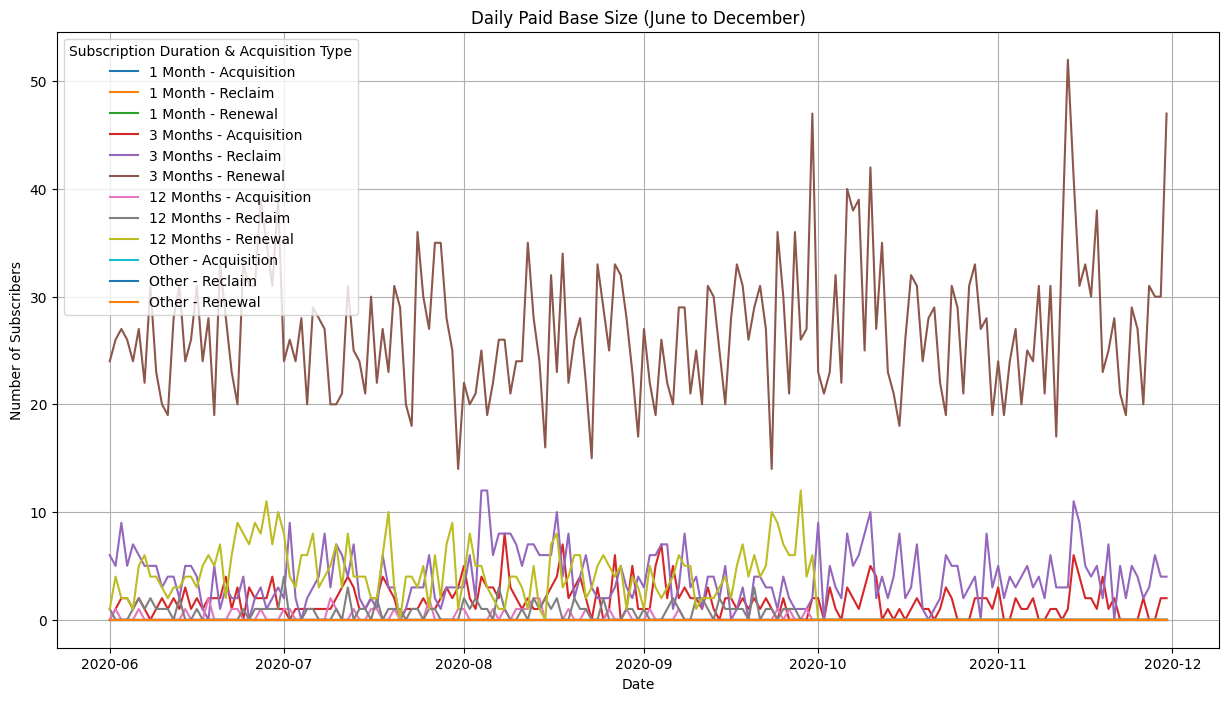

In [ ]:
# Plot the data
plt.figure(figsize=(15, 8))
for sub_duration in daily_data_pivot.columns.levels[0]:
    for acquisition_type in daily_data_pivot.columns.levels[1]:
        plt.plot(daily_data_pivot.index, daily_data_pivot[(sub_duration, acquisition_type)], label=f'{sub_duration} - {acquisition_type}')

plt.title('Daily Paid Base Size (June to December)')
plt.xlabel('Date')
plt.ylabel('Number of Subscribers')
plt.legend(title='Subscription Duration & Acquisition Type')
plt.grid(True)
plt.show()


Q6: Using knowledge of the gaming industry, explain the findings.

### **Key findings**

Visualizations reveal an upward trend in paid subscriptions over the observed period (June to December). This growth is observed due to various factors:

*   **Seasonality:** Gaming industry typically experiences increased activity during the holiday season (November and December). This is when people are more likely to purchase games and consoles, leading to a surge in subscriptions.

*  **Marketing Campaigns:** Targeted marketing campaigns and promotions drive new subscriptions and reclaims. Promotions often coincide with major game releases or holidays, further amplifying their impact.



**Monthly Paid Net Growth:** Bar graph indicates significant growth in September(back-to-school promotions, release of new game titles), followed by a slight decline in October and November before a significant surge in December.

**Daily Paid Base Size:** Area plot illustrates the daily fluctuations in paid base, broken down by subscription duration and acquisition type.

* **Subscription Duration:** Distribution of subscribers across 1, 3, and 12-month durations provides insight into consumer preferences and behavior.

### **Gaming Industry Knowledge**

* Gaming market is heavily influenced by seasonality, with peaks during holidays and major game releases.

* Marketing strategies, competitive dynamics, and pricing models play crucial roles in attracting and retaining subscribers.


**Project Findings**

This project findings underscore the importance of understanding these trends to make informed business decisions. By analyzing the data, **EliteEdge** can:

* Optimize marketing campaigns to coincide with periods of high
  demand.

* Adjust pricing strategies to incentivize longer-term
  subscriptions.